# Полная проверка DXA-пайплайна на размеченных данных

Ноутбук загружает единый `dxa_qc_pipeline_bundle.pt`, прогоняет все DICOM из
`labels.csv` и сравнивает результаты с разметкой:

1. часть тела: `SPINE`, `LEG_LEFT`, `LEG_RIGHT`;
2. металл для снимков бедра;
3. доступные автоматические QC-проверки с целями из `разметка.xlsx`;
4. 30 стратифицированно-случайных изображений с таргетами и предсказаниями.

**Важно:** этот прогон включает изображения, использованные при обучении. Он проверяет
целостность данных и работоспособность пайплайна, но не заменяет независимый test set.
Метрики на всём наборе будут оптимистичными.


## Как запускать

1. Поместите этот ноутбук и `dxa_inference_pipeline.py` в
   `C:\Users\Андрей\Desktop\Хакатон`.
2. Откройте ноутбук в VS Code или Jupyter и выберите kernel окружения
   `ml_env_py311`.
3. Проверьте только значение `PROJECT_ROOT` в следующей ячейке.
4. Выполните **Run All**. Обучение моделей заново не запускается.

Первый полный прогон сохранит кэш `prototype_output/full_dataset_predictions.csv`.
Повторный запуск использует кэш, пока не изменились bundle или `labels.csv`.
Для принудительного пересчёта задайте `FORCE_RECOMPUTE = True`.


In [1]:
from pathlib import Path, PurePosixPath
import importlib.util
import json
import math
import re
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tqdm.auto import tqdm

# Единственная обязательная настройка.
PROJECT_ROOT = Path(r"C:\Users\Андрей\Desktop\Хакатон")

PIPELINE_PY = PROJECT_ROOT / "dxa_inference_pipeline.py"
BUNDLE_PATH = PROJECT_ROOT / "prototype_output" / "dxa_qc_pipeline_bundle.pt"
TASK_TABLE_PATH = PROJECT_ROOT / "разметка.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "prototype_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS_CANDIDATES = [
    PROJECT_ROOT / "Размеченные" / "labels.csv",
    PROJECT_ROOT / "labels.csv",
    PROJECT_ROOT / "Исследования" / "labels.csv",
]
LABELS_CSV = next((path for path in LABELS_CANDIDATES if path.exists()), None)

PREDICTIONS_CSV = OUTPUT_DIR / "full_dataset_predictions.csv"
CACHE_META_JSON = OUTPUT_DIR / "full_dataset_predictions.meta.json"
SAMPLE_CSV = OUTPUT_DIR / "random_30_predictions.csv"
SUMMARY_JSON = OUTPUT_DIR / "full_dataset_evaluation_summary.json"

RANDOM_SEED = 42
SAMPLE_SIZE = 30
FORCE_RECOMPUTE = False
USE_SAM = False  # True требует checkpoint SAM и значительно замедляет прогон.
SAM_CHECKPOINT = PROJECT_ROOT / "sam_vit_b_01ec64.pth"
DEVICE = None    # None = автоматически CUDA, если она доступна.

# В присланной таблице 0 соответствует отсутствию нарушения, 1 — нарушению.
ONE_MEANS_VIOLATION = True

required = {
    "dxa_inference_pipeline.py": PIPELINE_PY,
    "bundle": BUNDLE_PATH,
    "labels.csv": LABELS_CSV,
    "разметка.xlsx": TASK_TABLE_PATH,
}
missing = [f"{name}: {path}" for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError("Не найдены обязательные файлы:\n" + "\n".join(missing))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LABELS_CSV:", LABELS_CSV)
print("BUNDLE_PATH:", BUNDLE_PATH)
print("TASK_TABLE_PATH:", TASK_TABLE_PATH)


PROJECT_ROOT: C:\Users\Андрей\Desktop\Хакатон
LABELS_CSV: C:\Users\Андрей\Desktop\Хакатон\Размеченные\labels.csv
BUNDLE_PATH: C:\Users\Андрей\Desktop\Хакатон\prototype_output\dxa_qc_pipeline_bundle.pt
TASK_TABLE_PATH: C:\Users\Андрей\Desktop\Хакатон\разметка.xlsx


## 1. Загрузка единого пайплайна

Статус `READY` означает, что архитектуры checkpoint совместимы, веса загружены,
классы анатомии и порог metal-head прочитаны из bundle.


In [2]:
spec = importlib.util.spec_from_file_location("dxa_inference_pipeline", PIPELINE_PY)
if spec is None or spec.loader is None:
    raise ImportError(f"Не удалось импортировать {PIPELINE_PY}")

dxa = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = dxa
spec.loader.exec_module(dxa)

pipeline = dxa.DXAInferencePipeline(
    bundle_path=BUNDLE_PATH,
    sam_checkpoint=SAM_CHECKPOINT if USE_SAM else None,
    device=DEVICE,
)
health = pipeline.health_check()
display(pd.Series(health, name="pipeline"))
assert health["status"] == "READY"


status                                                                               READY
device                                                                                cuda
model_source                             C:\Users\Андрей\Desktop\Хакатон\prototype_outp...
anatomy_classes                                {'SPINE': 0, 'LEG_LEFT': 1, 'LEG_RIGHT': 2}
metal_threshold                                                                   0.000417
metal_score_is_calibrated_probability                                                False
sam_checkpoint_available                                                             False
warnings                                 [Порог metal-head экстремально мал; metal_scor...
Name: pipeline, dtype: object

## 2. Загрузка поизображенческой разметки

`labels.csv` является источником таргетов для маршрутизатора части тела и metal-head.
Ноутбук проверяет существование каждого файла и поддерживает относительные пути от
корня проекта, папки `Исследования` или папки `Размеченные`.


In [3]:
def normalize_relpath(value):
    return str(value or "").strip().replace("\\", "/").lstrip("./")


def resolve_dicom_path(value):
    text = str(value or "").strip()
    direct = Path(text)
    if direct.is_absolute() and direct.exists():
        return direct

    relative = Path(*PurePosixPath(normalize_relpath(text)).parts)
    bases = [PROJECT_ROOT, PROJECT_ROOT / "Исследования", PROJECT_ROOT / "Размеченные"]
    for base in bases:
        candidate = base / relative
        if candidate.exists():
            return candidate
    return bases[0] / relative


labels = pd.read_csv(LABELS_CSV, dtype=str).fillna("")
required_columns = {"relative_path", "label"}
absent_columns = required_columns - set(labels.columns)
if absent_columns:
    raise ValueError(f"В labels.csv отсутствуют столбцы: {sorted(absent_columns)}")

for optional in ("side", "metal"):
    if optional not in labels.columns:
        labels[optional] = ""

labels["source_row_id"] = np.arange(len(labels), dtype=int)
labels["label"] = labels["label"].astype(str).str.strip().str.upper()
labels["side"] = labels["side"].astype(str).str.strip().str.upper()
labels["relative_path"] = labels["relative_path"].map(normalize_relpath)
labels["dicom_path"] = labels["relative_path"].map(resolve_dicom_path)

labels["target_anatomy"] = np.select(
    [
        labels["label"].eq("SPINE"),
        labels["label"].isin(["LEG", "HIP"]) & labels["side"].eq("LEFT"),
        labels["label"].isin(["LEG", "HIP"]) & labels["side"].eq("RIGHT"),
        labels["label"].eq("LEG_LEFT"),
        labels["label"].eq("LEG_RIGHT"),
    ],
    ["SPINE", "LEG_LEFT", "LEG_RIGHT", "LEG_LEFT", "LEG_RIGHT"],
    default="",
)

metal_numeric = pd.to_numeric(labels["metal"], errors="coerce")
is_leg_target = labels["target_anatomy"].isin(["LEG_LEFT", "LEG_RIGHT"])
labels["metal_target"] = metal_numeric.where(is_leg_target & metal_numeric.isin([0, 1]))

labels["file_exists"] = labels["dicom_path"].map(Path.exists)
missing_files = labels.loc[~labels["file_exists"], ["relative_path", "dicom_path"]]

dataset_summary = pd.DataFrame(
    {
        "value": {
            "rows_in_labels": len(labels),
            "existing_dicom": int(labels["file_exists"].sum()),
            "missing_dicom": int((~labels["file_exists"]).sum()),
            "anatomy_targets": int(labels["target_anatomy"].ne("").sum()),
            "metal_targets": int(labels["metal_target"].notna().sum()),
            "metal_positive": int(labels["metal_target"].eq(1).sum()),
        }
    }
)
display(dataset_summary)
display(labels["target_anatomy"].replace("", "UNKNOWN").value_counts().rename("count").to_frame())

if len(missing_files):
    display(missing_files.head(20))
    raise FileNotFoundError(f"Не найдено DICOM: {len(missing_files)}. Исправьте пути до полного прогона.")


,value
rows_in_labels,499
existing_dicom,499
missing_dicom,0
anatomy_targets,498
metal_targets,332
metal_positive,4


,count
target_anatomy,
LEG_LEFT,168
SPINE,166
LEG_RIGHT,164
UNKNOWN,1


## 3. Инференс на всех изображениях

Для каждого файла запускается полный доступный пайплайн. Для metal-head дополнительно
рассчитывается `metal_pred_given_target_leg`: эта величина проверяет сам metal-head на
всех истинных снимках бедра, даже если маршрутизатор ошибочно отправил изображение в
другой класс.

- `metal_pred_end_to_end` оценивает весь каскад: ошибка маршрутизатора считается
  пропуском металла;
- `metal_pred_given_target_leg` оценивает только metal-head при известной анатомии.


In [4]:
def file_signature(path):
    stat = Path(path).stat()
    return {"path": str(Path(path).resolve()), "size": stat.st_size, "mtime_ns": stat.st_mtime_ns}


expected_meta = {
    "cache_version": 2,
    "bundle": file_signature(BUNDLE_PATH),
    "labels": file_signature(LABELS_CSV),
    "row_count": int(len(labels)),
    "use_sam": bool(USE_SAM),
}


def cache_is_current():
    if FORCE_RECOMPUTE or not PREDICTIONS_CSV.exists() or not CACHE_META_JSON.exists():
        return False
    try:
        actual = json.loads(CACHE_META_JSON.read_text(encoding="utf-8"))
        return actual == expected_meta
    except Exception:
        return False


def flatten_result(result):
    flat = dict(result)
    scores = flat.pop("anatomy_scores", {}) or {}
    for class_name, score in scores.items():
        flat[f"anatomy_score_{class_name}"] = score
    return flat


def run_one(row):
    path = Path(row.dicom_path)
    with warnings.catch_warnings():
        # В наборе есть синтаксически невалидные UID. Это дефект метаданных,
        # но он не мешает чтению PixelData и инференсу.
        warnings.filterwarnings("ignore", message="Invalid value for VR UI.*")
        result = pipeline.process_image(
            path,
            use_sam=USE_SAM,
            allow_partial_quality=False,
        )

    flat = flatten_result(result)
    record = {
        "source_row_id": int(row.source_row_id),
        "relative_path": row.relative_path,
        "dicom_path": str(path),
        "label": row.label,
        "side": row.side,
        "target_anatomy": row.target_anatomy,
        "metal_target": row.metal_target,
        **flat,
    }

    is_true_leg = row.target_anatomy in {"LEG_LEFT", "LEG_RIGHT"}
    succeeded = flat.get("processing_status") == "Success"
    if is_true_leg and succeeded:
        # End-to-end: если истинный снимок бедра ошибочно направлен как SPINE,
        # проверка металла не была вызвана, что трактуется как отрицательный ответ.
        record["metal_pred_end_to_end"] = int(flat.get("metal_pred", 0))
        record["metal_score_end_to_end"] = flat.get("metal_score", np.nan)

        if flat.get("anatomical_region") in {"LEG_LEFT", "LEG_RIGHT"} and "metal_pred" in flat:
            record["metal_pred_given_target_leg"] = int(flat["metal_pred"])
            record["metal_score_given_target_leg"] = flat.get("metal_score", np.nan)
        else:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="Invalid value for VR UI.*")
                _, image, _, _ = dxa.preprocess_dicom(
                    path, pipeline.config.background_quantile
                )
            metal = pipeline.predict_metal(image)
            record["metal_pred_given_target_leg"] = int(metal["metal_pred"])
            record["metal_score_given_target_leg"] = metal["metal_score"]
    return record


if cache_is_current():
    predictions = pd.read_csv(PREDICTIONS_CSV, low_memory=False)
    print("Загружен актуальный кэш:", PREDICTIONS_CSV)
else:
    started = time.perf_counter()
    rows = [run_one(row) for row in tqdm(labels.itertuples(index=False), total=len(labels), desc="DXA inference")]
    predictions = pd.DataFrame(rows).sort_values("source_row_id").reset_index(drop=True)
    predictions.to_csv(PREDICTIONS_CSV, index=False, encoding="utf-8-sig")
    CACHE_META_JSON.write_text(json.dumps(expected_meta, ensure_ascii=False, indent=2), encoding="utf-8")
    elapsed = time.perf_counter() - started
    print(f"Обработано {len(predictions)} изображений за {elapsed:.1f} с")
    print("Кэш сохранён:", PREDICTIONS_CSV)

# Нормализация типов после загрузки CSV-кэша.
for column in (
    "source_row_id", "metal_target", "metal_pred", "metal_pred_end_to_end",
    "metal_pred_given_target_leg", "metal_score", "metal_score_end_to_end",
    "metal_score_given_target_leg", "anatomy_confidence", "time_of_processing",
):
    if column in predictions:
        predictions[column] = pd.to_numeric(predictions[column], errors="coerce")

display(predictions.head())


DXA inference:   0%|          | 0/499 [00:00<?, ?it/s]

Обработано 499 изображений за 14.6 с
Кэш сохранён: C:\Users\Андрей\Desktop\Хакатон\prototype_output\full_dataset_predictions.csv


,source_row_id,relative_path,dicom_path,label,side,target_anatomy,metal_target,path_to_study,path_to_image,study_uid,...,right_margin_ok,hip_roi_ok,metal_score,metal_score_is_calibrated_probability,metal_threshold,metal_pred,metal_pred_end_to_end,metal_score_end_to_end,metal_pred_given_target_leg,metal_score_given_target_leg
0,0,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,SPINE,,SPINE,NaN,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,1.2.643.5.1.13.13.12.2.77.8252.081107030913101...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG,RIGHT,LEG_RIGHT,0.0,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,1.2.643.5.1.13.13.12.2.77.8252.081107030913101...,...,NaN,NaN,0.000003,False,0.000417,0.0,0.0,0.000003,0.0,0.000003
2,2,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG,LEFT,LEG_LEFT,0.0,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,1.2.643.5.1.13.13.12.2.77.8252.081107030913101...,...,NaN,NaN,0.000007,False,0.000417,0.0,0.0,0.000007,0.0,0.000007
3,3,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG,LEFT,LEG_LEFT,0.0,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,1.2.643.5.1.13.13.12.2.77.8252.081107030913101...,...,NaN,NaN,0.000007,False,0.000417,0.0,0.0,0.000007,0.0,0.000007
4,4,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG,RIGHT,LEG_RIGHT,0.0,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,1.2.643.5.1.13.13.12.2.77.8252.081107030913101...,...,NaN,NaN,0.000003,False,0.000417,0.0,0.0,0.000003,0.0,0.000003


## 4. Полнота и техническая работоспособность

`processing_status=Success` показывает, что DICOM прочитан и пайплайн завершил обработку.
`qc_complete=False` не обязательно является ошибкой: он ожидаем при отсутствующем
`PixelSpacing`, выключенном SAM или пока не реализованной проверке позиции/ротации.


In [5]:
success_mask = predictions["processing_status"].eq("Success")
technical_summary = pd.DataFrame(
    {
        "value": {
            "images_total": len(predictions),
            "processing_success": int(success_mask.sum()),
            "processing_failure": int((~success_mask).sum()),
            "qc_complete": int(predictions.get("qc_complete", pd.Series(False, index=predictions.index)).eq(True).sum()),
            "pixel_spacing_available": int(predictions.get("pixel_spacing_available", pd.Series(False, index=predictions.index)).eq(True).sum()),
            "partial_quality": int(predictions.get("partial_quality_class", pd.Series(index=predictions.index, dtype=object)).eq("QUALITY").sum()),
            "partial_violation": int(predictions.get("partial_quality_class", pd.Series(index=predictions.index, dtype=object)).eq("VIOLATION").sum()),
            "mean_processing_seconds": float(predictions.loc[success_mask, "time_of_processing"].mean()),
        }
    }
)
display(technical_summary)

skipped = (
    predictions.loc[success_mask, "checks_skipped"]
    .fillna("")
    .str.split(";")
    .explode()
    .loc[lambda series: series.ne("")]
    .value_counts()
    .rename("images")
    .to_frame()
)
display(skipped)

failures = predictions.loc[
    ~success_mask,
    [column for column in ["dicom_path", "error_type", "error_message"] if column in predictions],
]
if len(failures):
    display(failures)
else:
    print("Все DICOM обработаны без технических ошибок.")


,value
images_total,499.000000
processing_success,499.000000
processing_failure,0.000000
qc_complete,0.000000
pixel_spacing_available,0.000000
partial_quality,448.000000
partial_violation,51.000000
mean_processing_seconds,0.028685


,images
checks_skipped,
HIP_ROI_NO_PIXEL_SPACING,333
HIP_POSITION_ROTATION_AUTO,333
SCOLIOSIS_DECISION,166
SPINE_ARTIFACT,166
SPINE_ROI,166
SPINE_COVERAGE,166


Все DICOM обработаны без технических ошибок.


## 5. Метрики маршрутизатора части тела

Основная метрика здесь — матрица ошибок между `target_anatomy` из `labels.csv` и
`anatomical_region` из модели. Дополнительно выводятся accuracy, balanced accuracy,
macro-F1 и показатели по каждому классу.


,n,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,498,1.0,1.0,1.0,1.0


,precision,recall,f1-score,support
SPINE,1.0,1.0,1.0,166.0
LEG_LEFT,1.0,1.0,1.0,168.0
LEG_RIGHT,1.0,1.0,1.0,164.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,498.0
weighted avg,1.0,1.0,1.0,498.0


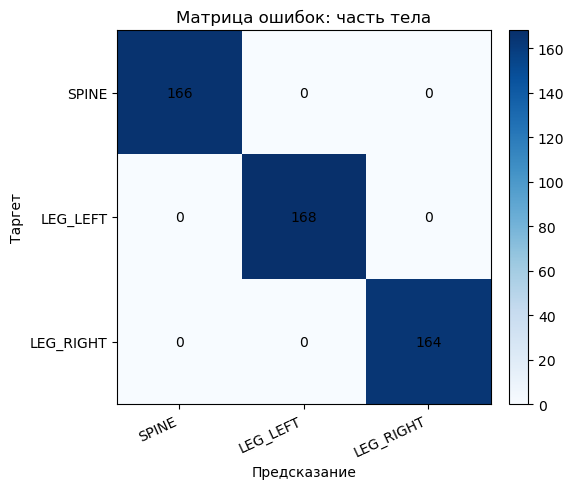

Ошибок маршрутизатора: 0


,dicom_path,target_anatomy,anatomical_region,anatomy_confidence


In [6]:
class_order = [name for name, index in sorted(pipeline.class_to_idx.items(), key=lambda item: item[1])]
anatomy_eval = predictions.loc[
    success_mask & predictions["target_anatomy"].isin(class_order)
].copy()
anatomy_eval["anatomy_correct"] = anatomy_eval["target_anatomy"].eq(anatomy_eval["anatomical_region"])

y_true_anatomy = anatomy_eval["target_anatomy"]
y_pred_anatomy = anatomy_eval["anatomical_region"]

anatomy_metrics = pd.DataFrame(
    [{
        "n": len(anatomy_eval),
        "accuracy": accuracy_score(y_true_anatomy, y_pred_anatomy),
        "balanced_accuracy": balanced_accuracy_score(y_true_anatomy, y_pred_anatomy),
        "f1_macro": f1_score(y_true_anatomy, y_pred_anatomy, labels=class_order, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true_anatomy, y_pred_anatomy, labels=class_order, average="weighted", zero_division=0),
    }]
)
display(anatomy_metrics)

anatomy_report = pd.DataFrame(
    classification_report(
        y_true_anatomy,
        y_pred_anatomy,
        labels=class_order,
        target_names=class_order,
        output_dict=True,
        zero_division=0,
    )
).T
display(anatomy_report)

cm_anatomy = confusion_matrix(y_true_anatomy, y_pred_anatomy, labels=class_order)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm_anatomy, cmap="Blues")
ax.set_xticks(range(len(class_order)), class_order, rotation=25, ha="right")
ax.set_yticks(range(len(class_order)), class_order)
ax.set_xlabel("Предсказание")
ax.set_ylabel("Таргет")
ax.set_title("Матрица ошибок: часть тела")
for i in range(len(class_order)):
    for j in range(len(class_order)):
        ax.text(j, i, str(cm_anatomy[i, j]), ha="center", va="center")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

anatomy_errors = anatomy_eval.loc[
    ~anatomy_eval["anatomy_correct"],
    ["dicom_path", "target_anatomy", "anatomical_region", "anatomy_confidence"]
].sort_values("anatomy_confidence", ascending=False)
print("Ошибок маршрутизатора:", len(anatomy_errors))
display(anatomy_errors.head(30))


## 6. Метрики обнаружения металла

Показаны две оценки: для полного каскада и отдельно для metal-head при известном истинном
классе бедра. Из-за четырёх положительных изображений показатели нестабильны. Особенно
важно смотреть на `sensitivity`, число `FN` и сами значения `metal_score`, а не только
на accuracy.


,evaluation,n,positive,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,roc_auc,pr_auc
0,end_to_end,332,4,328,0,2,2,0.993976,0.5,1.0,1.0,0.75,0.666667,0.555556,1.0,1.0
1,metal_head_given_true_leg,332,4,328,0,2,2,0.993976,0.5,1.0,1.0,0.75,0.666667,0.555556,1.0,1.0


,dicom_path,target_anatomy,anatomical_region,metal_target,metal_score_given_target_leg,metal_pred_given_target_leg,metal_pred_end_to_end
83,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,1.0,0.999981,1.0,1.0
82,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,1.0,0.999765,1.0,1.0
40,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,1.0,0.000395,0.0,0.0
45,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,1.0,0.000395,0.0,0.0
376,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.0,0.000361,0.0,0.0
378,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.0,0.000361,0.0,0.0
370,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.0,0.000361,0.0,0.0
371,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.0,0.000361,0.0,0.0
425,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.0,0.000330,0.0,0.0
424,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.0,0.000330,0.0,0.0


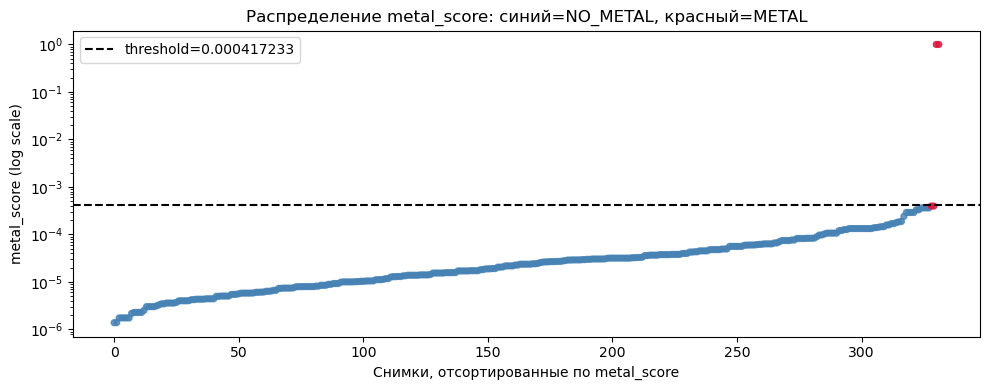

In [7]:
def binary_metrics(frame, pred_col, score_col, name):
    part = frame.loc[
        frame["metal_target"].isin([0, 1])
        & frame[pred_col].isin([0, 1])
    ].copy()
    y_true = part["metal_target"].astype(int).to_numpy()
    y_pred = part[pred_col].astype(int).to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    row = {
        "evaluation": name,
        "n": len(part),
        "positive": int((y_true == 1).sum()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }
    scores = pd.to_numeric(part[score_col], errors="coerce")
    score_mask = scores.notna()
    if score_mask.sum() and np.unique(y_true[score_mask]).size == 2:
        row["roc_auc"] = roc_auc_score(y_true[score_mask], scores[score_mask])
        row["pr_auc"] = average_precision_score(y_true[score_mask], scores[score_mask])
    else:
        row["roc_auc"] = np.nan
        row["pr_auc"] = np.nan
    return row


metal_eval = predictions.loc[success_mask & predictions["metal_target"].isin([0, 1])].copy()
metal_metrics = pd.DataFrame([
    binary_metrics(
        metal_eval,
        "metal_pred_end_to_end",
        "metal_score_end_to_end",
        "end_to_end",
    ),
    binary_metrics(
        metal_eval,
        "metal_pred_given_target_leg",
        "metal_score_given_target_leg",
        "metal_head_given_true_leg",
    ),
])
display(metal_metrics)

metal_review = metal_eval[[
    "dicom_path", "target_anatomy", "anatomical_region", "metal_target",
    "metal_score_given_target_leg", "metal_pred_given_target_leg",
    "metal_pred_end_to_end",
]].sort_values("metal_score_given_target_leg", ascending=False)
display(metal_review.head(30))

score_frame = metal_eval.dropna(subset=["metal_score_given_target_leg"]).sort_values("metal_score_given_target_leg")
if len(score_frame):
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = np.where(score_frame["metal_target"].astype(int).eq(1), "crimson", "steelblue")
    ax.scatter(
        np.arange(len(score_frame)),
        score_frame["metal_score_given_target_leg"].clip(lower=1e-12),
        c=colors,
        s=18,
        alpha=0.8,
    )
    ax.axhline(pipeline.metal_threshold, color="black", linestyle="--", label=f"threshold={pipeline.metal_threshold:.6g}")
    ax.set_yscale("log")
    ax.set_xlabel("Снимки, отсортированные по metal_score")
    ax.set_ylabel("metal_score (log scale)")
    ax.set_title("Распределение metal_score: синий=NO_METAL, красный=METAL")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 7. Разметка свойств исследования из `разметка.xlsx`

Таблица содержит многоуровневый заголовок и таргеты на уровне исследования. Код ниже
восстанавливает названия полей, показывает найденные соответствия и пытается связать
`study` из Excel с DICOM по:

- компонентам пути;
- стандартным UID из результата пайплайна;
- любому совпадающему полю DICOM-заголовка.

Если совпадений нет, ноутбук честно покажет нулевое покрытие и не будет связывать строки
по порядку, поскольку такое сопоставление могло бы дать ложные метрики.


In [8]:
UID_LIKE_RE = re.compile(r"^[0-9]+(?:\.[0-9]+)+$")


def load_task_table(path):
    raw = pd.read_excel(path, header=None, dtype=str).fillna("")
    uid_counts = {
        column: raw[column].astype(str).str.strip().map(lambda value: bool(UID_LIKE_RE.match(value))).sum()
        for column in raw.columns
    }
    study_column = max(uid_counts, key=uid_counts.get)
    if uid_counts[study_column] == 0:
        raise ValueError("В разметка.xlsx не найден столбец study с UID-подобными значениями")

    is_data = raw[study_column].astype(str).str.strip().map(lambda value: bool(UID_LIKE_RE.match(value)))
    first_data_row = int(np.flatnonzero(is_data.to_numpy())[0])
    header_rows = raw.iloc[:first_data_row].astype(str)
    top_header = (
        header_rows.iloc[0].replace("", np.nan).ffill().fillna("")
        if len(header_rows) else pd.Series("", index=raw.columns)
    )

    names = {}
    for column in raw.columns:
        tokens = [value.strip() for value in header_rows[column].tolist() if value.strip()]
        if top_header[column] and (not tokens or top_header[column] != tokens[0]):
            tokens.insert(0, top_header[column])
        names[column] = " | ".join(dict.fromkeys(tokens)) or f"column_{column}"

    data = raw.loc[is_data].copy()
    data.columns = [names[column] for column in raw.columns]
    data = data.rename(columns={names[study_column]: "study"})
    data["study"] = data["study"].astype(str).str.strip()

    def normalized(text):
        return re.sub(r"\s+", " ", str(text).lower().replace("ё", "е").replace("\xa0", " ")).strip()

    def find_column(*groups, prefix=None):
        for column in data.columns:
            text = normalized(column)
            if prefix is not None and not text.startswith(normalized(prefix)):
                continue
            if all(any(key in text for key in group) for group in groups):
                return column
        return None

    mapping = {
        "spine_coverage": find_column(("корректн",), ("укладк",), prefix="позвоночник"),
        "spine_alignment": find_column(("выравнен",), ("ось",), prefix="позвоночник"),
        "spine_artifacts": find_column(("посторон", "артеф", "налож"), prefix="позвоночник"),
        "right_hip_position_rotation": find_column(("позиционир", "ротац"), prefix="проксимальный отдел правого бедра"),
        "right_hip_roi": find_column(("област", "интерес"), prefix="проксимальный отдел правого бедра"),
        "left_hip_position_rotation": find_column(("позиционир", "ротац"), prefix="проксимальный отдел левого бедра"),
        "left_hip_roi": find_column(("област", "интерес"), prefix="проксимальный отдел левого бедра"),
        "spine_total": find_column(("позвоноч",), prefix="итог"),
        "right_hip_total": find_column(("прав",), ("бедр",), prefix="итог"),
        "left_hip_total": find_column(("лев",), ("бедр",), prefix="итог"),
        "comment": find_column(("комментар",), prefix="итог"),
    }

    out = pd.DataFrame({"study": data["study"]})
    for task, column in mapping.items():
        if column is None:
            continue
        if task == "comment":
            out[task] = data[column].astype(str).str.strip()
        else:
            out[task] = pd.to_numeric(data[column], errors="coerce")
    if "comment" in out:
        out["scoliosis_from_comment"] = out["comment"].str.contains("сколиоз", case=False, na=False).astype(int)
    return out.reset_index(drop=True), mapping


task_labels, task_mapping = load_task_table(TASK_TABLE_PATH)
mapping_table = pd.DataFrame(
    {"task": list(task_mapping), "excel_column": [task_mapping[key] for key in task_mapping]}
)
display(mapping_table)
print("Строк исследований в Excel:", len(task_labels))
display(task_labels.head())

target_studies = set(task_labels["study"].astype(str))


def task_study_from_dicom(row):
    candidates = set()
    path = Path(row.dicom_path)
    candidates.update(part.strip() for part in path.parts if str(part).strip())
    for column in ("study_uid", "image_uid"):
        value = str(getattr(row, column, "") or "").strip()
        if value:
            candidates.add(value)

    direct_matches = candidates & target_studies
    if len(direct_matches) == 1:
        return next(iter(direct_matches))

    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Invalid value for VR UI.*")
            ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)
        for element in ds.iterall():
            if element.VR == "SQ":
                continue
            value = element.value
            if isinstance(value, (str, bytes)):
                values = [value]
            else:
                try:
                    values = list(value)
                except TypeError:
                    values = [value]
            for item in values:
                text = str(item).strip()
                if text in target_studies:
                    candidates.add(text)
    except Exception:
        return np.nan

    matches = candidates & target_studies
    return next(iter(matches)) if len(matches) == 1 else np.nan


if "task_study" not in predictions or predictions["task_study"].notna().sum() == 0:
    predictions["task_study"] = [
        task_study_from_dicom(row)
        for row in tqdm(predictions.itertuples(index=False), total=len(predictions), desc="Сопоставление с Excel")
    ]

linked_images = int(predictions["task_study"].notna().sum())
linked_studies = int(predictions["task_study"].nunique(dropna=True))
link_summary = pd.DataFrame(
    {"value": {
        "excel_studies": len(task_labels),
        "linked_studies": linked_studies,
        "linked_images": linked_images,
        "study_coverage": linked_studies / len(task_labels) if len(task_labels) else np.nan,
    }}
)
display(link_summary)
if linked_studies == 0:
    print(
        "UID из Excel не найден среди путей или DICOM-тегов. "
        "Для проверки свойств нужна отдельная таблица соответствия Excel study ↔ DICOM/папка."
    )


,task,excel_column
0,spine_coverage,Позвоночник | корректная укладка
1,spine_alignment,Позвоночник | правильно выравнена ось позвоноч...
2,spine_artifacts,"Позвоночник | наличие посторонних предметов, в..."
3,right_hip_position_rotation,Проксимальный отдел правого бедра | позиционир...
4,right_hip_roi,Проксимальный отдел правого бедра | корректнос...
5,left_hip_position_rotation,Проксимальный отдел левого бедра | позициониро...
6,left_hip_roi,Проксимальный отдел левого бедра | корректност...
7,spine_total,Итог | Позвоночник
8,right_hip_total,Итог | Проксимальный отдел правого бедра
9,left_hip_total,Итог | Проксимальный отдел левого бедра


Строк исследований в Excel: 100


,study,spine_coverage,spine_alignment,spine_artifacts,right_hip_position_rotation,right_hip_roi,left_hip_position_rotation,left_hip_roi,spine_total,right_hip_total,left_hip_total,comment,scoliosis_from_comment
0,2.25.306921081709806079165809721263236241032,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,,0
1,2.25.307021710202910067378603383388989711646,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,,0
2,2.25.309085571913348252136520206003694446566,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,,0
3,2.25.314147167453134440746270747484612743945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,0
4,2.25.338439598607961312040815816824093323492,0.0,0.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,сколиоз,1


Сопоставление с Excel:   0%|          | 0/499 [00:00<?, ?it/s]

,value
excel_studies,100.0
linked_studies,100.0
linked_images,499.0
study_coverage,1.0


## 8. Сверка доступных QC-свойств

Для каждой пары `study + часть тела` выбирается один успешно обработанный снимок с
максимальной уверенностью маршрутизатора. Оцениваются только проверки, для которых
одновременно существуют таргет и автоматическое предсказание.

Проверки артефактов позвоночника и позиции/ротации бедра пока не реализованы и поэтому
помечаются `NOT_IMPLEMENTED`. ROI бедра невозможно оценить без `PixelSpacing`. Проверка
покрытия позвоночника доступна только при `USE_SAM=True`.


In [9]:
def as_bool_series(series):
    if series.dtype == bool:
        return series.astype("boolean")
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.map({"true": True, "false": False, "1": True, "0": False}).astype("boolean")


def best_body_image(region):
    part = predictions.loc[
        predictions["task_study"].notna()
        & predictions["target_anatomy"].eq(region)
        & predictions["processing_status"].eq("Success")
    ].copy()
    if part.empty:
        return part
    part["anatomy_confidence"] = pd.to_numeric(part["anatomy_confidence"], errors="coerce")
    return (
        part.sort_values(["task_study", "anatomy_confidence"], ascending=[True, False])
        .drop_duplicates("task_study")
    )


best_spine = best_body_image("SPINE")
best_right = best_body_image("LEG_RIGHT")
best_left = best_body_image("LEG_LEFT")

if len(best_spine) and "spine_axis_angle_deg" in best_spine:
    angles = pd.to_numeric(best_spine["spine_axis_angle_deg"], errors="coerce")
    alignment_prediction = pd.Series(pd.NA, index=best_spine.index, dtype="Int64")
    available = angles.notna()
    alignment_prediction.loc[available] = (
        angles.loc[available].abs() > pipeline.config.spine_max_tilt_deg
    ).astype(int)
    best_spine["pred_spine_alignment_violation"] = alignment_prediction
    if "spine_coverage_ok" in best_spine:
        coverage_ok = as_bool_series(best_spine["spine_coverage_ok"])
        best_spine["pred_spine_coverage_violation"] = (~coverage_ok).astype("Int64")

for frame in (best_right, best_left):
    if len(frame) and "hip_roi_ok" in frame:
        roi_ok = as_bool_series(frame["hip_roi_ok"])
        frame["pred_hip_roi_violation"] = (~roi_ok).astype("Int64")


def qc_metric_row(task_name, target_column, prediction_frame, prediction_column):
    if target_column not in task_labels:
        return {"task": task_name, "status": "TARGET_NOT_FOUND", "evaluable_studies": 0}
    if prediction_column not in prediction_frame:
        return {"task": task_name, "status": "PREDICTION_NOT_AVAILABLE", "evaluable_studies": 0}

    merged = task_labels[["study", target_column]].merge(
        prediction_frame[["task_study", prediction_column]],
        left_on="study",
        right_on="task_study",
        how="inner",
    )
    target = pd.to_numeric(merged[target_column], errors="coerce")
    prediction = pd.to_numeric(merged[prediction_column], errors="coerce")
    valid = target.isin([0, 1]) & prediction.isin([0, 1])
    target = target[valid].astype(int)
    prediction = prediction[valid].astype(int)
    if not ONE_MEANS_VIOLATION:
        target = 1 - target
    if len(target) == 0:
        return {"task": task_name, "status": "NO_EVALUABLE_PAIRS", "evaluable_studies": 0}

    tn, fp, fn, tp = confusion_matrix(target, prediction, labels=[0, 1]).ravel()
    return {
        "task": task_name,
        "status": "OK",
        "evaluable_studies": len(target),
        "target_violations": int(target.sum()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "accuracy": accuracy_score(target, prediction),
        "sensitivity": recall_score(target, prediction, zero_division=0),
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "f1": f1_score(target, prediction, zero_division=0),
    }


qc_rows = [
    qc_metric_row(
        "spine_alignment",
        "spine_alignment",
        best_spine,
        "pred_spine_alignment_violation",
    ),
    qc_metric_row(
        "spine_coverage",
        "spine_coverage",
        best_spine,
        "pred_spine_coverage_violation",
    ),
    qc_metric_row(
        "right_hip_roi",
        "right_hip_roi",
        best_right,
        "pred_hip_roi_violation",
    ),
    qc_metric_row(
        "left_hip_roi",
        "left_hip_roi",
        best_left,
        "pred_hip_roi_violation",
    ),
    {"task": "spine_artifacts", "status": "NOT_IMPLEMENTED", "evaluable_studies": 0},
    {"task": "right_hip_position_rotation", "status": "NOT_IMPLEMENTED", "evaluable_studies": 0},
    {"task": "left_hip_position_rotation", "status": "NOT_IMPLEMENTED", "evaluable_studies": 0},
    {"task": "scoliosis_decision", "status": "NOT_IMPLEMENTED", "evaluable_studies": 0},
]
qc_metrics = pd.DataFrame(qc_rows)
display(qc_metrics)


,task,status,evaluable_studies,target_violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,f1
0,spine_alignment,OK,99,10.0,70.0,19.0,5.0,5.0,0.757576,0.5,0.786517,0.294118
1,spine_coverage,PREDICTION_NOT_AVAILABLE,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,right_hip_roi,NO_EVALUABLE_PAIRS,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,left_hip_roi,NO_EVALUABLE_PAIRS,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,spine_artifacts,NOT_IMPLEMENTED,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,right_hip_position_rotation,NOT_IMPLEMENTED,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,left_hip_position_rotation,NOT_IMPLEMENTED,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,scoliosis_decision,NOT_IMPLEMENTED,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Тридцать случайных примеров

Используется воспроизводимая стратифицированная случайная выборка: по возможности по
10 изображений каждого класса. Цвет рамки зелёный при совпадении таргета и предсказания,
красный при ошибке. Для бедра дополнительно указаны таргет и end-to-end предсказание
металла.


,dicom_path,target_anatomy,anatomical_region,anatomy_confidence,anatomy_correct,metal_target,metal_score_given_target_leg,metal_pred_end_to_end,target_properties,predicted_properties,partial_quality_class,violation_type
0,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,0.999998,True,0.0,0.000083,0.0,position_rotation=0; roi=0; metal=0; total=0,hip_roi_ok=?; metal_pred=0; metal_score=0.000083,QUALITY,
1,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.999595,True,0.0,0.000019,0.0,position_rotation=0; roi=1; metal=0; total=1,hip_roi_ok=?; metal_pred=0; metal_score=0.000019,QUALITY,
2,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,0.999999,True,0.0,0.000006,0.0,position_rotation=0; roi=0; metal=0; total=0,hip_roi_ok=?; metal_pred=0; metal_score=0.000006,QUALITY,
3,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.999993,True,0.0,0.000017,0.0,position_rotation=0; roi=0; metal=0; total=0,hip_roi_ok=?; metal_pred=0; metal_score=0.000017,QUALITY,
4,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,SPINE,SPINE,0.999872,True,NaN,NaN,NaN,alignment=0; coverage=1; artifacts=0; total=1,axis_angle_deg=0.085; scoliosis_proxy_deg=8.79...,QUALITY,
5,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,SPINE,SPINE,0.999878,True,NaN,NaN,NaN,alignment=0; coverage=0; artifacts=1; total=1,axis_angle_deg=6.319; scoliosis_proxy_deg=28.7...,VIOLATION,SPINE_ALIGNMENT
6,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,0.999994,True,0.0,0.000040,0.0,position_rotation=1; roi=0; metal=0; total=1,hip_roi_ok=?; metal_pred=0; metal_score=0.000040,QUALITY,
7,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,LEG_RIGHT,0.999954,True,0.0,0.000016,0.0,position_rotation=0; roi=0; metal=0; total=0,hip_roi_ok=?; metal_pred=0; metal_score=0.000016,QUALITY,
8,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,LEG_LEFT,0.999963,True,0.0,0.000145,0.0,position_rotation=1; roi=0; metal=0; total=1,hip_roi_ok=?; metal_pred=0; metal_score=0.000145,QUALITY,
9,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,SPINE,SPINE,0.999692,True,NaN,NaN,NaN,alignment=0; coverage=0; artifacts=1; total=1,axis_angle_deg=3.982; scoliosis_proxy_deg=48.2...,QUALITY,


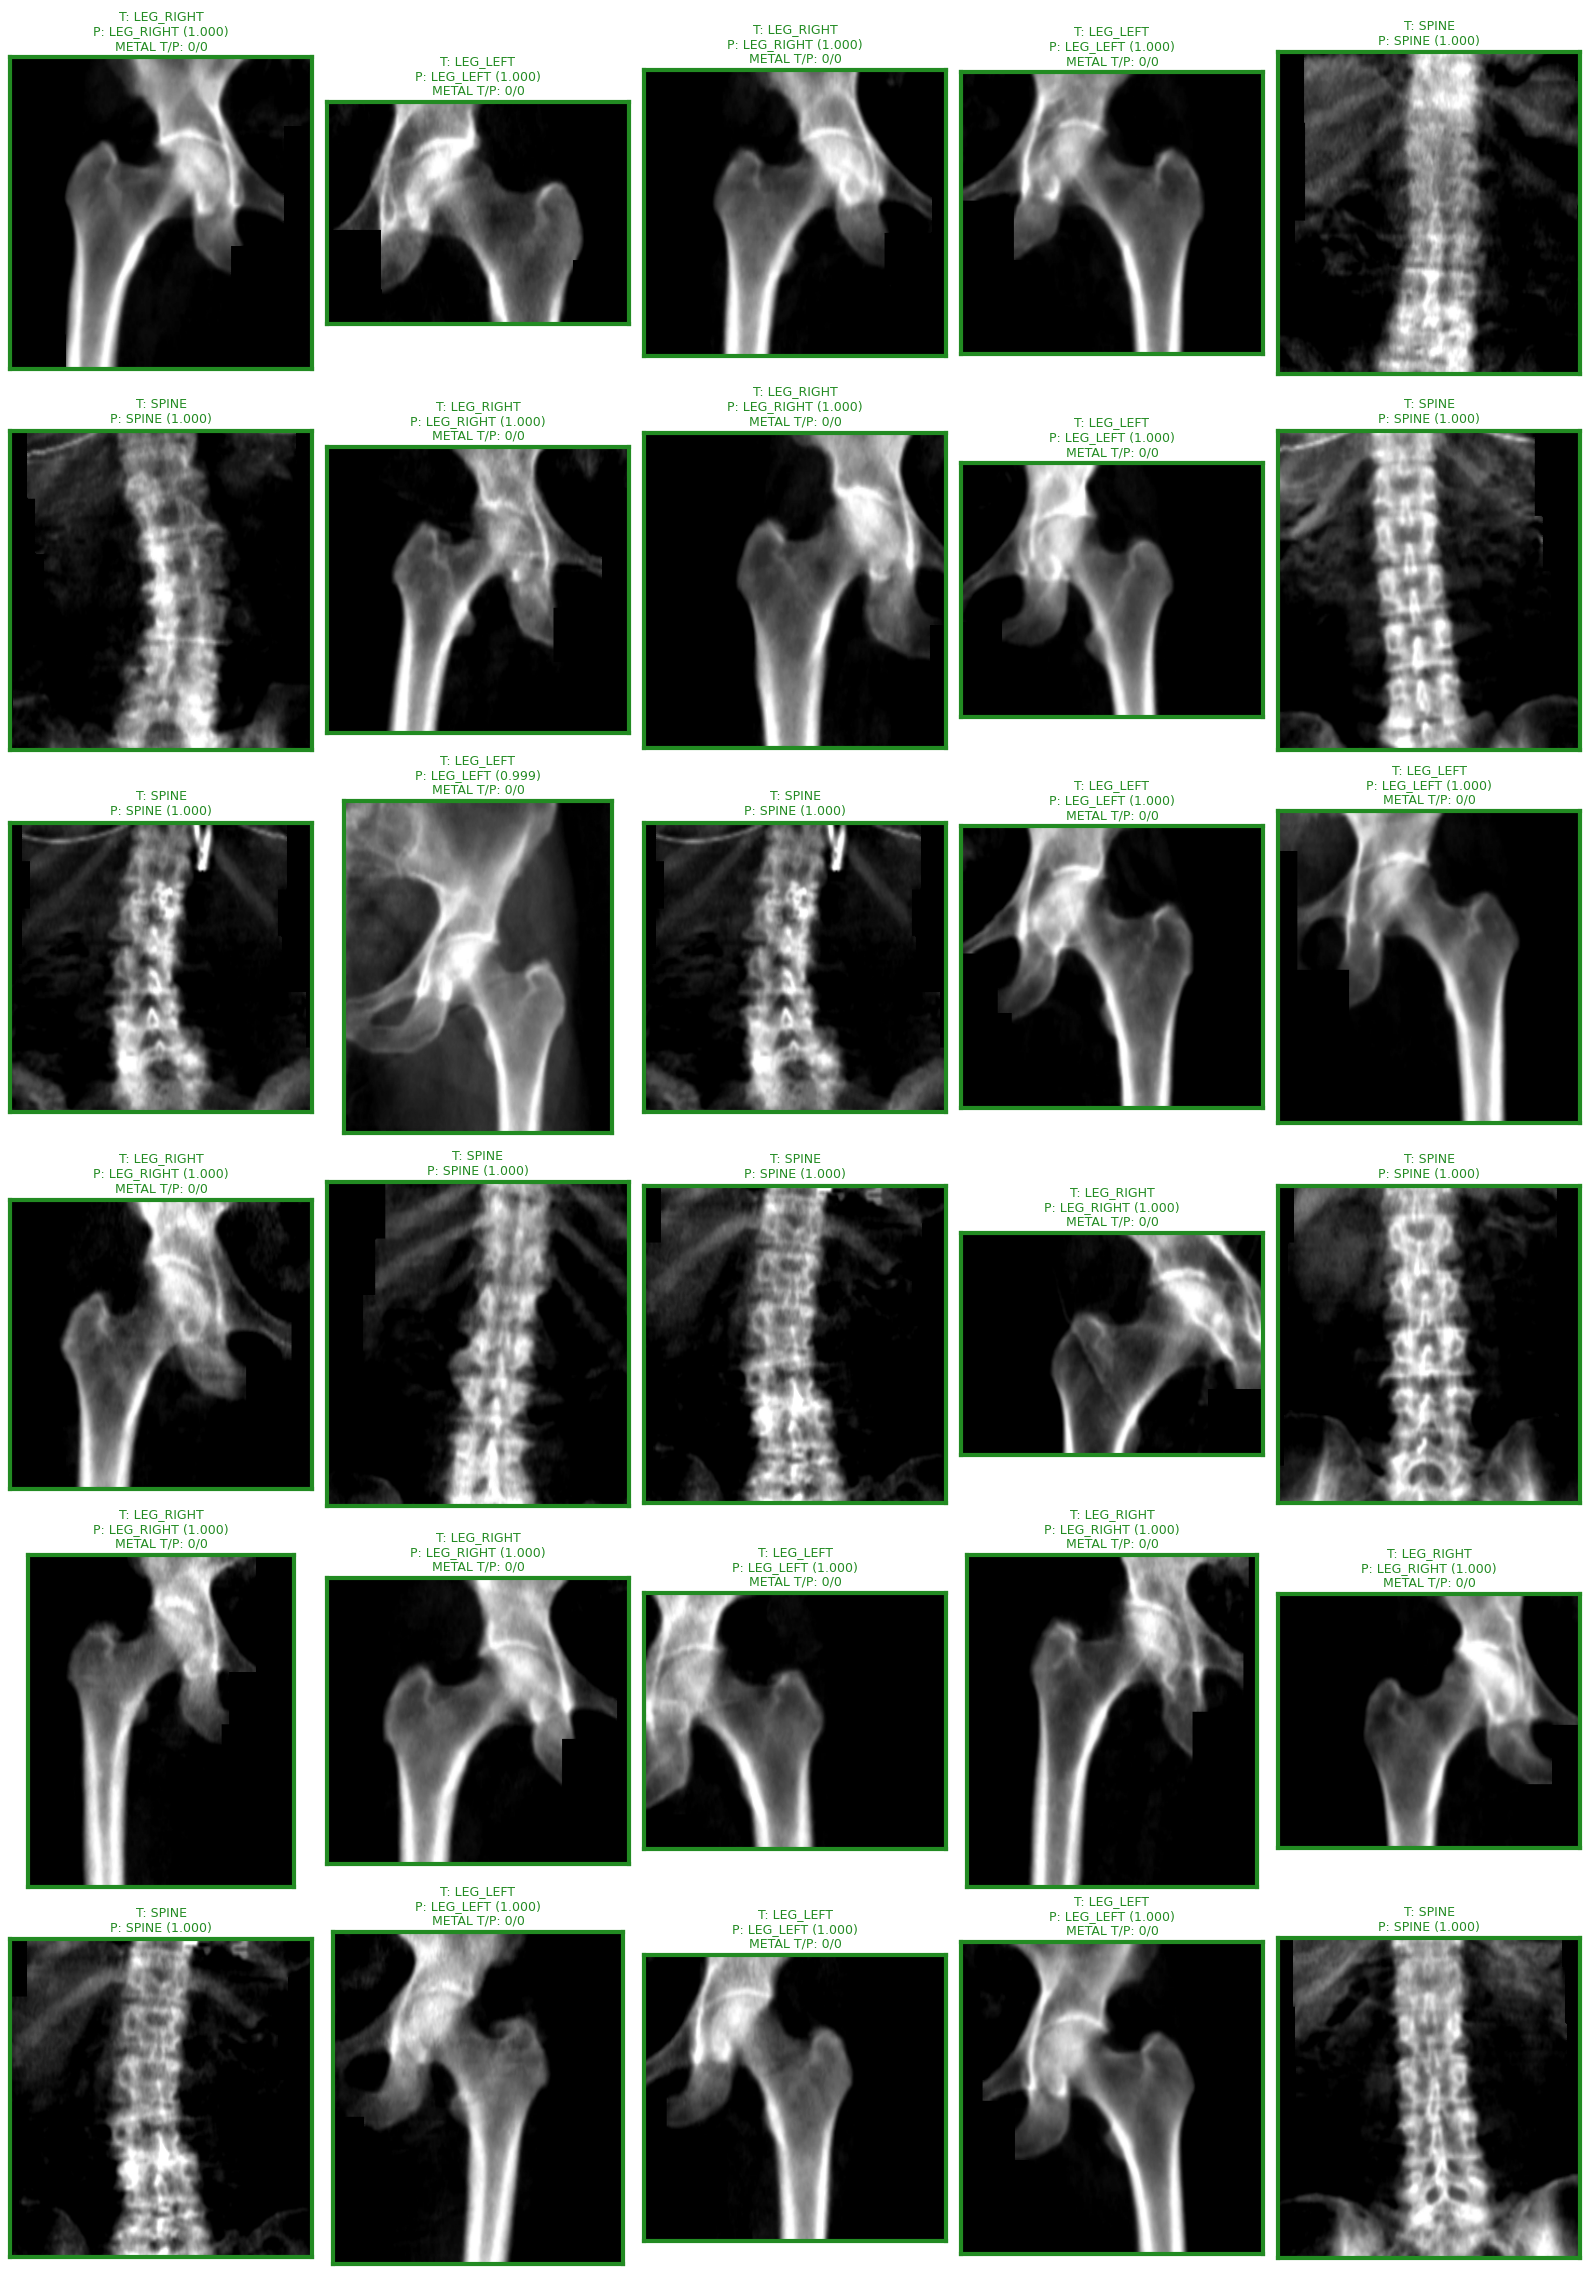

In [10]:
def stratified_random_sample(frame, n, seed):
    pool = frame.loc[
        frame["processing_status"].eq("Success")
        & frame["target_anatomy"].isin(class_order)
    ].copy()
    rng = np.random.default_rng(seed)
    classes = [name for name in class_order if pool["target_anatomy"].eq(name).any()]
    base = n // len(classes)
    selected_indices = []
    for class_name in classes:
        indices = pool.index[pool["target_anatomy"].eq(class_name)].to_numpy()
        take = min(base, len(indices))
        selected_indices.extend(rng.choice(indices, size=take, replace=False).tolist())
    remaining = n - len(selected_indices)
    if remaining > 0:
        candidates = pool.index.difference(selected_indices).to_numpy()
        take = min(remaining, len(candidates))
        selected_indices.extend(rng.choice(candidates, size=take, replace=False).tolist())
    return pool.loc[selected_indices].sample(frac=1, random_state=seed).reset_index(drop=True)


sample_30 = stratified_random_sample(predictions, SAMPLE_SIZE, RANDOM_SEED)
sample_targets = task_labels.rename(
    columns={column: f"target_xlsx_{column}" for column in task_labels.columns if column != "study"}
)
sample_30 = sample_30.merge(
    sample_targets,
    left_on="task_study",
    right_on="study",
    how="left",
)
sample_30["anatomy_correct"] = sample_30["target_anatomy"].eq(sample_30["anatomical_region"])

def short_value(value, digits=3):
    if pd.isna(value):
        return "?"
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}f}"
    return str(value)

def target_properties(row):
    if row.target_anatomy == "SPINE":
        return (
            f"alignment={short_value(getattr(row, 'target_xlsx_spine_alignment', np.nan), 0)}; "
            f"coverage={short_value(getattr(row, 'target_xlsx_spine_coverage', np.nan), 0)}; "
            f"artifacts={short_value(getattr(row, 'target_xlsx_spine_artifacts', np.nan), 0)}; "
            f"total={short_value(getattr(row, 'target_xlsx_spine_total', np.nan), 0)}"
        )
    side = "left" if row.target_anatomy == "LEG_LEFT" else "right"
    return (
        f"position_rotation={short_value(getattr(row, f'target_xlsx_{side}_hip_position_rotation', np.nan), 0)}; "
        f"roi={short_value(getattr(row, f'target_xlsx_{side}_hip_roi', np.nan), 0)}; "
        f"metal={short_value(row.metal_target, 0)}; "
        f"total={short_value(getattr(row, f'target_xlsx_{side}_hip_total', np.nan), 0)}"
    )

def predicted_properties(row):
    if row.anatomical_region == "SPINE":
        return (
            f"axis_angle_deg={short_value(getattr(row, 'spine_axis_angle_deg', np.nan))}; "
            f"scoliosis_proxy_deg={short_value(getattr(row, 'scoliosis_proxy_deg', np.nan))}; "
            f"coverage_ok={short_value(getattr(row, 'spine_coverage_ok', np.nan))}"
        )
    return (
        f"hip_roi_ok={short_value(getattr(row, 'hip_roi_ok', np.nan))}; "
        f"metal_pred={short_value(getattr(row, 'metal_pred_end_to_end', np.nan), 0)}; "
        f"metal_score={short_value(getattr(row, 'metal_score_given_target_leg', np.nan), 6)}"
    )

sample_30["target_properties"] = [target_properties(row) for row in sample_30.itertuples(index=False)]
sample_30["predicted_properties"] = [predicted_properties(row) for row in sample_30.itertuples(index=False)]
sample_columns = [
    "dicom_path", "target_anatomy", "anatomical_region", "anatomy_confidence",
    "anatomy_correct", "metal_target", "metal_score_given_target_leg",
    "metal_pred_end_to_end", "target_properties", "predicted_properties",
    "partial_quality_class", "violation_type",
]
display(sample_30[[column for column in sample_columns if column in sample_30]])

n_columns = 5
n_rows = math.ceil(len(sample_30) / n_columns)
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 3.8 * n_rows))
axes = np.atleast_1d(axes).ravel()

for axis, row in zip(axes, sample_30.itertuples(index=False)):
    path = Path(row.dicom_path)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Invalid value for VR UI.*")
        _, image = dxa.read_dicom_image(path)
    axis.imshow(image, cmap="gray")
    correct = row.target_anatomy == row.anatomical_region
    color = "forestgreen" if correct else "crimson"
    title = (
        f"T: {row.target_anatomy}\n"
        f"P: {row.anatomical_region} ({row.anatomy_confidence:.3f})"
    )
    if row.target_anatomy in {"LEG_LEFT", "LEG_RIGHT"}:
        metal_target = "?" if pd.isna(row.metal_target) else str(int(row.metal_target))
        metal_pred = "?" if pd.isna(row.metal_pred_end_to_end) else str(int(row.metal_pred_end_to_end))
        title += f"\nMETAL T/P: {metal_target}/{metal_pred}"
    axis.set_title(title, fontsize=9, color=color)
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

for axis in axes[len(sample_30):]:
    axis.axis("off")
plt.tight_layout()
plt.show()


## 10. Сохранение результатов

Сохраняются полная таблица предсказаний, выбранные 30 примеров и краткая сводка. Эти
файлы можно передавать вместе с bundle для воспроизводимой проверки.


In [11]:
predictions.to_csv(PREDICTIONS_CSV, index=False, encoding="utf-8-sig")
sample_30.to_csv(SAMPLE_CSV, index=False, encoding="utf-8-sig")

summary_payload = {
    "pipeline_health": health,
    "dataset": {key: (value.item() if hasattr(value, "item") else value) for key, value in dataset_summary["value"].items()},
    "technical": {key: (value.item() if hasattr(value, "item") else value) for key, value in technical_summary["value"].items()},
    "anatomy_metrics": anatomy_metrics.to_dict(orient="records"),
    "metal_metrics": metal_metrics.replace({np.nan: None}).to_dict(orient="records"),
    "excel_link": {key: (value.item() if hasattr(value, "item") else value) for key, value in link_summary["value"].items()},
    "qc_metrics": qc_metrics.replace({np.nan: None}).to_dict(orient="records"),
    "limitations": [
        "Оценка выполнена на полном наборе, включающем обучающие изображения",
        "metal_score не является калиброванной вероятностью",
        "Положительных металлических изображений крайне мало",
        "Часть QC-проверок не реализована или требует PixelSpacing/SAM",
    ],
}
SUMMARY_JSON.write_text(json.dumps(summary_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("Полные предсказания:", PREDICTIONS_CSV)
print("30 случайных примеров:", SAMPLE_CSV)
print("Сводка:", SUMMARY_JSON)


Полные предсказания: C:\Users\Андрей\Desktop\Хакатон\prototype_output\full_dataset_predictions.csv
30 случайных примеров: C:\Users\Андрей\Desktop\Хакатон\prototype_output\random_30_predictions.csv
Сводка: C:\Users\Андрей\Desktop\Хакатон\prototype_output\full_dataset_evaluation_summary.json


## Как интерпретировать результат

- Высокая accuracy части тела подтверждает, что маршрутизация работает на текущем наборе.
  Для итоговой оценки всё равно нужен отдельный test set или внешние исследования.
- Для металла смотрите `sensitivity`, `FN` и разделение `metal_score`. Четырёх
  положительных изображений недостаточно для надёжной клинической валидации.
- `qc_complete=False` ожидаем, пока отсутствуют автоматические проверки всех свойств.
- `HIP_ROI_NO_PIXEL_SPACING` означает, что геометрия найдена в пикселях, но сантиметровые
  отступы 3/3/2 см нельзя проверить без физического размера пикселя.
- Предупреждение pydicom о `Invalid value for VR UI` указывает на нестрого сформированные
  UID в исходных метаданных. Обработка PixelData при этом может завершаться успешно.
- Если `linked_studies=0`, свойства из Excel нельзя корректно сравнить без таблицы
  соответствия идентификаторов. Связывать исследования по номеру строки нельзя.
